# 08 · Entrenamiento completo V5 · 1991–2017 → Validación 2018–2021

Este notebook toma los **mejores hiperparámetros obtenidos en la optimización intensiva V5**
y realiza el paso que faltaba:

1. Ajustar la climatología V5 usando exclusivamente el período de entrenamiento.
2. Construir las **192 características** para entrenamiento y validación.
3. Entrenar cada uno de los cinco modelos con **todo el entrenamiento disponible hasta 2017**.
4. Evaluarlos una sola vez sobre **2018–2021**.
5. Compararlos contra `Persistencia` y `Dummy`.

## Importante

Este notebook **NO utiliza**:

- `prueba_temporal` 2022–2025;
- `holdout_espacial`;
- `holdout_historia`.

Por tanto, el test final y el holdout espacial siguen cerrados.

## 0. Dependencias

In [1]:
%pip install -q scikit-learn xgboost joblib matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [2]:
from pathlib import Path
import importlib
import json
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports listos.")

Imports listos.


## 2. Localizar el proyecto

In [3]:
candidates = [
    Path.cwd(),
    Path.cwd() / "rain-threat-classifier",
    Path("/content/rain-threat-classifier"),
    Path("/content/drive/MyDrive/rain-threat-classifier"),
]

PROJECT_DIR = next(
    (
        p for p in candidates
        if (p / "resultados_completo" / "dataset_modelo_mensual_v3.csv").exists()
        and (p / "resultados_completo" / "columnas_modelo_v3.txt").exists()
        and (p / "resultados_completo" / "indicadores_mensuales_todas_zonas.csv").exists()
        and (p / "04_climatologia_era5land.py").exists()
        and (
            p
            / "resultados_experimentos"
            / "v5_optimizacion_intensiva"
            / "mejores_parametros_finales.json"
        ).exists()
    ),
    None,
)

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "No se encontró el proyecto o falta alguno de los archivos requeridos."
    )

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

clim = importlib.import_module("04_climatologia_era5land")
clim = importlib.reload(clim)

DATA_DIR = PROJECT_DIR / "resultados_completo"
TUNING_DIR = PROJECT_DIR / "resultados_experimentos" / "v5_optimizacion_intensiva"
OUTPUT_DIR = PROJECT_DIR / "resultados_experimentos" / "v5_validacion_2018_2021"

PRED_DIR = OUTPUT_DIR / "predicciones"
REPORT_DIR = OUTPUT_DIR / "reportes"
MODEL_DIR = OUTPUT_DIR / "modelos"

for directory in [OUTPUT_DIR, PRED_DIR, REPORT_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_DIR: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier
OUTPUT_DIR: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\resultados_experimentos\v5_validacion_2018_2021


## 3. Cargar datos y mejores hiperparámetros

In [4]:
DATASET_PATH = DATA_DIR / "dataset_modelo_mensual_v3.csv"
FEATURES_PATH = DATA_DIR / "columnas_modelo_v3.txt"
MONTHLY_PATH = DATA_DIR / "indicadores_mensuales_todas_zonas.csv"
PARAMS_PATH = TUNING_DIR / "mejores_parametros_finales.json"

df = pd.read_csv(DATASET_PATH)
df["period_start"] = pd.to_datetime(df["period_start"])
df["target_period_start"] = pd.to_datetime(df["target_period_start"])

monthly = pd.read_csv(MONTHLY_PATH)
monthly["period_start"] = pd.to_datetime(monthly["period_start"])

features_v3 = [
    line.strip()
    for line in FEATURES_PATH.read_text(encoding="utf-8").splitlines()
    if line.strip()
]

features_v5 = features_v3 + clim.CLIMATE_FEATURE_NAMES

with open(PARAMS_PATH, "r", encoding="utf-8") as file:
    best_params = json.load(file)

assert len(features_v3) == 167
assert len(clim.CLIMATE_FEATURE_NAMES) == 25
assert len(features_v5) == 192
assert "target_amenaza" not in features_v5
assert "target_rx5day_mm" not in features_v5

print("Dataset V3:", df.shape)
print("Features V3:", len(features_v3))
print("Features climatológicas:", len(clim.CLIMATE_FEATURE_NAMES))
print("Features V5 totales:", len(features_v5))
print("Modelos con parámetros:", list(best_params))

Dataset V3: (6120, 209)
Features V3: 167
Features climatológicas: 25
Features V5 totales: 192
Modelos con parámetros: ['Regresion_Logistica', 'Random_Forest', 'XGBoost', 'SVM_RBF', 'MLP']


## 4. Separar entrenamiento completo y validación temporal

In [5]:
train_df = df[df["split"] == "entrenamiento"].copy()
val_df = df[df["split"] == "validacion_temporal"].copy()

assert len(train_df) > 0
assert len(val_df) > 0
assert train_df["zone_id"].nunique() == 12
assert val_df["zone_id"].nunique() == 12
assert train_df["target_period_start"].max() < val_df["target_period_start"].min()

print("ENTRENAMIENTO")
print("Filas:", len(train_df))
print("Target:", train_df["target_period_start"].min().date(), "→", train_df["target_period_start"].max().date())

print("\nVALIDACIÓN")
print("Filas:", len(val_df))
print("Target:", val_df["target_period_start"].min().date(), "→", val_df["target_period_start"].max().date())

print("\nDistribución entrenamiento:")
display(train_df["target_amenaza"].value_counts(normalize=True).rename("proporcion").to_frame())

print("\nDistribución validación:")
display(val_df["target_amenaza"].value_counts(normalize=True).rename("proporcion").to_frame())

ENTRENAMIENTO
Filas: 3744
Target: 1992-01-01 → 2017-12-01

VALIDACIÓN
Filas: 576
Target: 2018-01-01 → 2021-12-01

Distribución entrenamiento:


,proporcion
target_amenaza,
Alta,0.333868
Media,0.333333
Baja,0.332799



Distribución validación:


,proporcion
target_amenaza,
Baja,0.350694
Alta,0.350694
Media,0.298611


## 5. Ajustar climatología V5 solo con entrenamiento

In [6]:
climate_cutoff = train_df["period_start"].max()
development_zones = train_df["zone_id"].unique()

climate_reference = clim.fit_climatology(
    monthly=monthly,
    cutoff=climate_cutoff,
    zones=development_zones,
)

X_train = clim.add_climate_features(
    frame=train_df,
    base_X=train_df[features_v3].copy(),
    reference=climate_reference,
)

X_val = clim.add_climate_features(
    frame=val_df,
    base_X=val_df[features_v3].copy(),
    reference=climate_reference,
)

assert X_train.shape[1] == 192
assert X_val.shape[1] == 192
assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert list(X_train.columns) == list(X_val.columns)

print("Climatología ajustada hasta:", climate_cutoff.date())
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

Climatología ajustada hasta: 2017-11-01
X_train: (3744, 192)
X_val: (576, 192)


## 6. Codificar target

In [7]:
label_encoder = LabelEncoder()
label_encoder.fit(train_df["target_amenaza"])

CLASS_NAMES = list(label_encoder.classes_)
y_train = label_encoder.transform(train_df["target_amenaza"])
y_val = label_encoder.transform(val_df["target_amenaza"])

print("Clases:", dict(enumerate(CLASS_NAMES)))

Clases: {0: 'Alta', 1: 'Baja', 2: 'Media'}


## 7. Métricas

In [8]:
def calculate_metrics(y_true, y_pred):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(len(CLASS_NAMES)),
        zero_division=0,
    )

    result = {
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    }

    for i, class_name in enumerate(CLASS_NAMES):
        key = class_name.lower()
        result[f"precision_{key}"] = float(precision[i])
        result[f"recall_{key}"] = float(recall[i])
        result[f"f1_{key}"] = float(f1[i])
        result[f"support_{key}"] = int(support[i])

    return result

## 8. Reconstruir modelos con los mejores hiperparámetros

In [9]:
models = {
    "Regresion_Logistica": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            solver="lbfgs",
            random_state=RANDOM_STATE,
        )),
    ]),
    "Random_Forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "SVM_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=False,
            cache_size=2048,
            random_state=RANDOM_STATE,
        )),
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            solver="adam",
            max_iter=800,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

def normalize_loaded_params(model_name, params):
    params = dict(params)
    if (
        model_name == "MLP"
        and "model__hidden_layer_sizes" in params
        and isinstance(params["model__hidden_layer_sizes"], list)
    ):
        params["model__hidden_layer_sizes"] = tuple(params["model__hidden_layer_sizes"])
    return params

for model_name in models:
    params = normalize_loaded_params(model_name, best_params[model_name])
    models[model_name].set_params(**params)
    print("\n", model_name)
    print(params)


 Regresion_Logistica
{'model__class_weight': 'balanced', 'model__C': 0.001}

 Random_Forest
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 32, 'class_weight': 'balanced', 'bootstrap': True}

 XGBoost
{'subsample': 1.0, 'reg_lambda': 10.0, 'reg_alpha': 0.0, 'n_estimators': 450, 'min_child_weight': 2, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.05, 'colsample_bytree': 0.85}

 SVM_RBF
{'model__gamma': 0.0005, 'model__class_weight': None, 'model__C': 3.0}

 MLP
{'model__validation_fraction': 0.15, 'model__n_iter_no_change': 20, 'model__learning_rate_init': 0.0001, 'model__hidden_layer_sizes': (192, 96, 48), 'model__batch_size': 128, 'model__alpha': 0.0003, 'model__activation': 'relu'}


## 9. Entrenamiento completo 1991–2017 y evaluación 2018–2021

In [10]:
validation_rows = []
validation_predictions = {}
fitted_models = {}

for model_name, model in models.items():
    print("\n" + "=" * 90)
    print("ENTRENANDO:", model_name)

    fit_start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - fit_start

    inference_start = time.perf_counter()
    pred = model.predict(X_val)
    inference_seconds = time.perf_counter() - inference_start

    metrics = calculate_metrics(y_val, pred)

    validation_rows.append({
        "modelo": model_name,
        **metrics,
        "fit_seconds": fit_seconds,
        "inference_seconds": inference_seconds,
    })

    validation_predictions[model_name] = pred
    fitted_models[model_name] = model

    print(
        f"Macro F1={metrics['macro_f1']:.6f} | "
        f"Balanced Accuracy={metrics['balanced_accuracy']:.6f} | "
        f"Recall Alta={metrics['recall_alta']:.6f} | "
        f"Fit={fit_seconds:.2f}s"
    )

    joblib.dump(model, MODEL_DIR / f"{model_name}.joblib")

ml_results = pd.DataFrame(validation_rows)


ENTRENANDO: Regresion_Logistica
Macro F1=0.452134 | Balanced Accuracy=0.471256 | Recall Alta=0.658416 | Fit=0.06s

ENTRENANDO: Random_Forest
Macro F1=0.417246 | Balanced Accuracy=0.419180 | Recall Alta=0.514851 | Fit=12.23s

ENTRENANDO: XGBoost
Macro F1=0.390990 | Balanced Accuracy=0.391127 | Recall Alta=0.450495 | Fit=4.54s

ENTRENANDO: SVM_RBF
Macro F1=0.436606 | Balanced Accuracy=0.454179 | Recall Alta=0.603960 | Fit=0.99s

ENTRENANDO: MLP
Macro F1=0.381603 | Balanced Accuracy=0.389036 | Recall Alta=0.490099 | Fit=4.11s


## 10. Baselines sobre 2018–2021

In [11]:
baseline_rows = []

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)

baseline_rows.append({
    "modelo": "Dummy",
    **calculate_metrics(y_val, dummy_pred),
    "fit_seconds": np.nan,
    "inference_seconds": np.nan,
})

persistence_pred = label_encoder.transform(val_df["amenaza_mes"])

baseline_rows.append({
    "modelo": "Persistencia",
    **calculate_metrics(y_val, persistence_pred),
    "fit_seconds": np.nan,
    "inference_seconds": np.nan,
})

baseline_results = pd.DataFrame(baseline_rows)

display(
    baseline_results[
        [
            "modelo",
            "macro_f1",
            "balanced_accuracy",
            "recall_alta",
            "f1_alta",
            "f1_baja",
            "f1_media",
        ]
    ]
)

,modelo,macro_f1,balanced_accuracy,recall_alta,f1_alta,f1_baja,f1_media
0,Dummy,0.173093,0.333333,1.000000,0.519280,0.000000,0.000000
1,Persistencia,0.409207,0.409068,0.480198,0.482587,0.449383,0.295652


## 11. Ranking completo de validación

In [12]:
validation_ranking = (
    pd.concat([ml_results, baseline_results], ignore_index=True)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(
    validation_ranking[
        [
            "modelo",
            "macro_f1",
            "balanced_accuracy",
            "recall_alta",
            "f1_alta",
            "f1_baja",
            "f1_media",
            "fit_seconds",
            "inference_seconds",
        ]
    ]
)

validation_ranking.to_csv(
    OUTPUT_DIR / "ranking_validacion_2018_2021.csv",
    index=False,
)

,modelo,macro_f1,balanced_accuracy,recall_alta,f1_alta,f1_baja,f1_media,fit_seconds,inference_seconds
0,Regresion_Logistica,0.452134,0.471256,0.658416,0.567164,0.541176,0.248062,0.055290,0.002895
1,SVM_RBF,0.436606,0.454179,0.603960,0.550790,0.535147,0.223881,0.993893,0.206823
2,Random_Forest,0.417246,0.419180,0.514851,0.501205,0.471744,0.278788,12.227514,0.093020
3,Persistencia,0.409207,0.409068,0.480198,0.482587,0.449383,0.295652,NaN,NaN
4,XGBoost,0.390990,0.391127,0.450495,0.461929,0.441247,0.269795,4.535274,0.013789
5,MLP,0.381603,0.389036,0.490099,0.474820,0.448513,0.221477,4.109555,0.003178
6,Dummy,0.173093,0.333333,1.000000,0.519280,0.000000,0.000000,NaN,NaN


## 12. Comparación con versiones anteriores

In [13]:
historical_reference = pd.DataFrame([
    {
        "version": "V1",
        "modelo": "MLP",
        "macro_f1_validacion_2018_2021": 0.409003,
    },
    {
        "version": "V3",
        "modelo": "Random_Forest",
        "macro_f1_validacion_2018_2021": 0.402850,
    },
    {
        "version": "Baseline",
        "modelo": "Persistencia",
        "macro_f1_validacion_2018_2021": 0.4092073182130144,
    },
])

current_reference = ml_results[["modelo", "macro_f1"]].copy()
current_reference["version"] = "V5 optimizada"
current_reference = current_reference.rename(
    columns={"macro_f1": "macro_f1_validacion_2018_2021"}
)

comparison_history = pd.concat(
    [historical_reference, current_reference],
    ignore_index=True,
).sort_values(
    "macro_f1_validacion_2018_2021",
    ascending=False,
)

display(comparison_history)

comparison_history.to_csv(
    OUTPUT_DIR / "comparacion_con_versiones_previas.csv",
    index=False,
)

,version,modelo,macro_f1_validacion_2018_2021
3,V5 optimizada,Regresion_Logistica,0.452134
6,V5 optimizada,SVM_RBF,0.436606
4,V5 optimizada,Random_Forest,0.417246
2,Baseline,Persistencia,0.409207
0,V1,MLP,0.409003
1,V3,Random_Forest,0.402850
5,V5 optimizada,XGBoost,0.390990
7,V5 optimizada,MLP,0.381603


## 13. Reportes por clase y matrices de confusión


Regresion_Logistica
              precision    recall  f1-score   support

        Alta     0.4981    0.6584    0.5672       202
        Baja     0.5157    0.5693    0.5412       202
       Media     0.3721    0.1860    0.2481       172

    accuracy                         0.4861       576
   macro avg     0.4620    0.4713    0.4521       576
weighted avg     0.4667    0.4861    0.4628       576



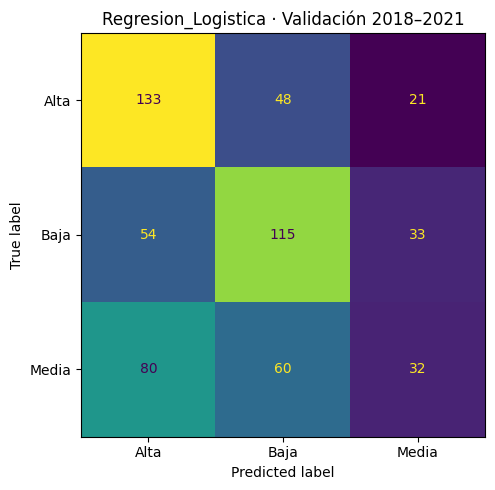


Random_Forest
              precision    recall  f1-score   support

        Alta     0.4883    0.5149    0.5012       202
        Baja     0.4683    0.4752    0.4717       202
       Media     0.2911    0.2674    0.2788       172

    accuracy                         0.4271       576
   macro avg     0.4159    0.4192    0.4172       576
weighted avg     0.4224    0.4271    0.4245       576



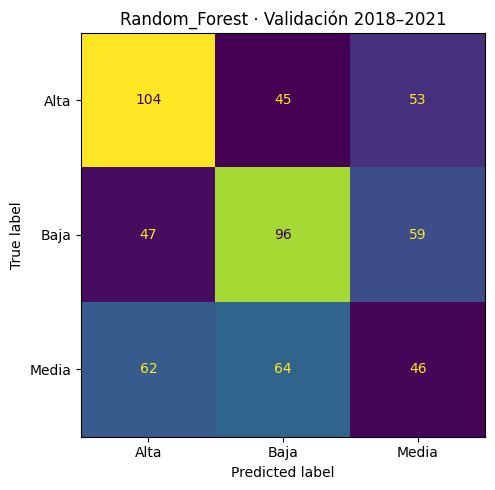


XGBoost
              precision    recall  f1-score   support

        Alta     0.4740    0.4505    0.4619       202
        Baja     0.4279    0.4554    0.4412       202
       Media     0.2722    0.2674    0.2698       172

    accuracy                         0.3976       576
   macro avg     0.3914    0.3911    0.3910       576
weighted avg     0.3976    0.3976    0.3973       576



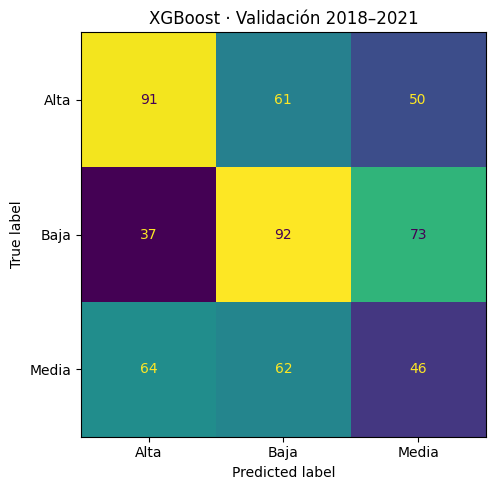


SVM_RBF
              precision    recall  f1-score   support

        Alta     0.5062    0.6040    0.5508       202
        Baja     0.4937    0.5842    0.5351       202
       Media     0.3125    0.1744    0.2239       172

    accuracy                         0.4688       576
   macro avg     0.4375    0.4542    0.4366       576
weighted avg     0.4440    0.4688    0.4477       576



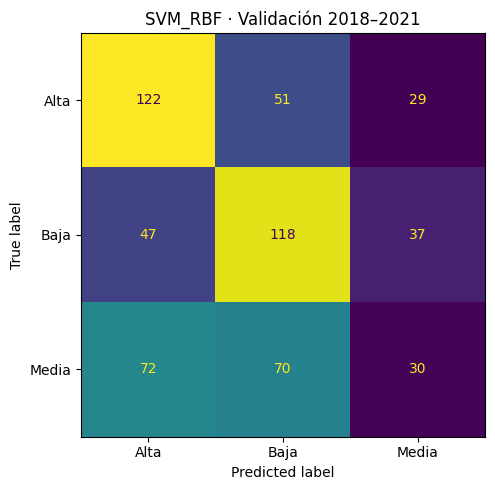


MLP
              precision    recall  f1-score   support

        Alta     0.4605    0.4901    0.4748       202
        Baja     0.4170    0.4851    0.4485       202
       Media     0.2619    0.1919    0.2215       172

    accuracy                         0.3993       576
   macro avg     0.3798    0.3890    0.3816       576
weighted avg     0.3859    0.3993    0.3899       576



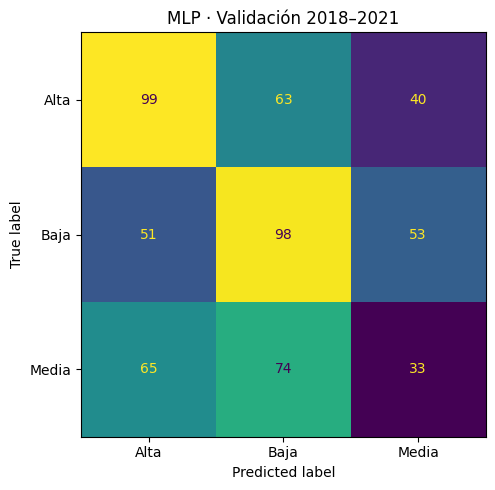


Dummy
              precision    recall  f1-score   support

        Alta     0.3507    1.0000    0.5193       202
        Baja     0.0000    0.0000    0.0000       202
       Media     0.0000    0.0000    0.0000       172

    accuracy                         0.3507       576
   macro avg     0.1169    0.3333    0.1731       576
weighted avg     0.1230    0.3507    0.1821       576



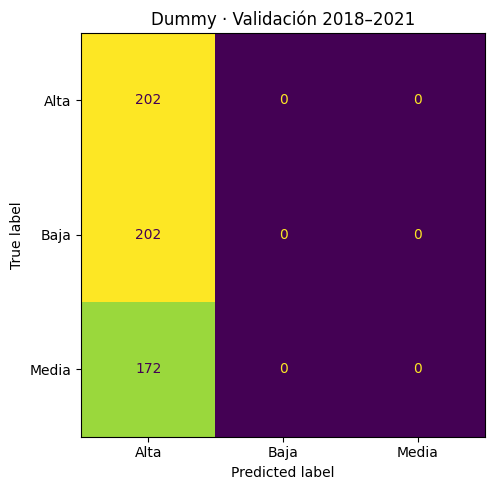


Persistencia
              precision    recall  f1-score   support

        Alta     0.4850    0.4802    0.4826       202
        Baja     0.4483    0.4505    0.4494       202
       Media     0.2948    0.2965    0.2957       172

    accuracy                         0.4149       576
   macro avg     0.4094    0.4091    0.4092       576
weighted avg     0.4153    0.4149    0.4151       576



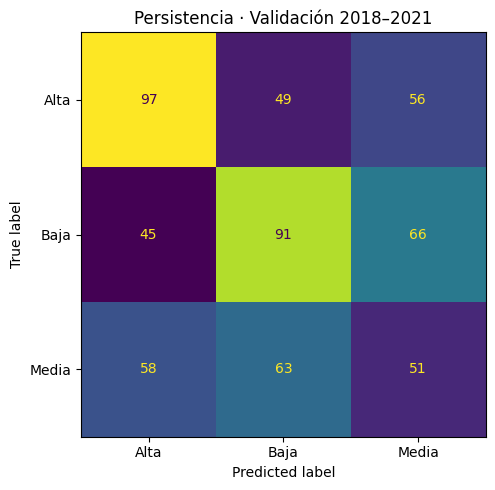

In [14]:
all_predictions = {
    **validation_predictions,
    "Dummy": dummy_pred,
    "Persistencia": persistence_pred,
}

for model_name, pred in all_predictions.items():
    print("\n" + "=" * 90)
    print(model_name)

    report = classification_report(
        y_val,
        pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
    print(report)

    (REPORT_DIR / f"{model_name}_classification_report.txt").write_text(
        report,
        encoding="utf-8",
    )

    cm = confusion_matrix(
        y_val,
        pred,
        labels=np.arange(len(CLASS_NAMES)),
    )

    pd.DataFrame(
        cm,
        index=[f"real_{c}" for c in CLASS_NAMES],
        columns=[f"pred_{c}" for c in CLASS_NAMES],
    ).to_csv(
        REPORT_DIR / f"{model_name}_confusion_matrix.csv"
    )

    fig, ax = plt.subplots(figsize=(5.5, 5))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES,
    ).plot(ax=ax, colorbar=False)

    ax.set_title(f"{model_name} · Validación 2018–2021")
    plt.tight_layout()
    plt.show()

## 14. Guardar predicciones fila por fila

In [15]:
prediction_base_columns = [
    col for col in [
        "zone_id",
        "ciudad",
        "provincia",
        "region",
        "period_start",
        "target_period_start",
        "amenaza_mes",
        "target_amenaza",
    ]
    if col in val_df.columns
]

for model_name, pred in all_predictions.items():
    pred_df = val_df[prediction_base_columns].copy()
    pred_df["prediccion"] = label_encoder.inverse_transform(np.asarray(pred, dtype=int))
    pred_df["correcto"] = (
        pred_df["prediccion"] == pred_df["target_amenaza"]
    ).astype(int)

    pred_df.to_csv(
        PRED_DIR / f"{model_name}_predicciones.csv",
        index=False,
    )

print("Predicciones guardadas en:", PRED_DIR)

Predicciones guardadas en: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\resultados_experimentos\v5_validacion_2018_2021\predicciones


## 15. Interpretación

Las preguntas que responde este notebook son:

1. ¿V5 optimizada supera el antiguo **MLP V1 ≈ 0.4090**?
2. ¿Supera el **RF V3 ≈ 0.4029**?
3. ¿Supera el baseline de **Persistencia ≈ 0.4092**?
4. ¿Qué ocurre con `Recall Alta` y con la clase `Media`?

Todavía **NO** se utiliza 2022–2025 ni el holdout espacial.

La reducción de características se estudia después de conocer este techo de V5 completa.